In [480]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from subprocess import check_output
import os
for dirname, _, filenames in os.walk("C:/Users/Admin/Documents/Lb2(pokemon)"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

C:/Users/Admin/Documents/Lb2(pokemon)\combats.csv
C:/Users/Admin/Documents/Lb2(pokemon)\pokemon.csv
C:/Users/Admin/Documents/Lb2(pokemon)\tests.csv


In [481]:
data = pd.read_csv('C:/Users/Admin/Documents/Lb2(pokemon)/pokemon.csv')
data.head()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [482]:
data.tail()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
795,796,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True
796,797,Mega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True
797,798,Hoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True
798,799,Hoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True
799,800,Volcanion,Fire,Water,80,110,120,130,90,70,6,True


In [483]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        799 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   HP          800 non-null    int64 
 5   Attack      800 non-null    int64 
 6   Defense     800 non-null    int64 
 7   Sp. Atk     800 non-null    int64 
 8   Sp. Def     800 non-null    int64 
 9   Speed       800 non-null    int64 
 10  Generation  800 non-null    int64 
 11  Legendary   800 non-null    bool  
dtypes: bool(1), int64(8), object(3)
memory usage: 69.7+ KB


In [484]:
data.shape

(800, 12)

In [485]:
data_comb = pd.read_csv('C:/Users/Admin/Documents/Lb2(pokemon)/combats.csv')
data_comb.head()

,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


In [486]:
data_comb.tail()

,First_pokemon,Second_pokemon,Winner
49995,707,126,707
49996,589,664,589
49997,303,368,368
49998,109,89,109
49999,9,73,9


In [487]:
data_comb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   50000 non-null  int64
 1   Second_pokemon  50000 non-null  int64
 2   Winner          50000 non-null  int64
dtypes: int64(3)
memory usage: 1.1 MB


In [488]:
data_comb.describe()

,First_pokemon,Second_pokemon,Winner
count,50000.000000,50000.000000,50000.000000
mean,400.495640,403.159660,408.890100
std,229.549429,230.083644,231.159961
min,1.000000,1.000000,1.000000
25%,203.000000,207.000000,206.000000
50%,399.000000,402.000000,422.000000
75%,597.250000,602.000000,606.000000
max,800.000000,800.000000,800.000000


In [489]:
wins = data_comb['Winner'].value_counts().reset_index()
wins.columns = ['ID', 'Wins']
wins = wins.merge(data, left_on='ID', right_on='#')
wins[['Name', 'Wins', 'Legendary']].head()

,Name,Wins,Legendary
0,Mewtwo,152,True
1,Infernape,136,False
2,Aerodactyl,136,False
3,Jirachi,134,True
4,Slaking,133,False


In [490]:
data_tests = pd.read_csv('C:/Users/Admin/Documents/Lb2(pokemon)/tests.csv')
data_tests.head()

,First_pokemon,Second_pokemon
0,129,117
1,660,211
2,706,115
3,195,618
4,27,656


In [491]:
data_tests.tail()

,First_pokemon,Second_pokemon
9995,216,498
9996,113,404
9997,493,104
9998,643,259
9999,678,531


In [492]:
data_tests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   First_pokemon   10000 non-null  int64
 1   Second_pokemon  10000 non-null  int64
dtypes: int64(2)
memory usage: 156.4 KB


In [493]:
data_tests.describe()

,First_pokemon,Second_pokemon
count,10000.000000,10000.000000
mean,402.071600,404.504500
std,230.045967,232.825149
min,1.000000,1.000000
25%,204.000000,202.000000
50%,404.000000,406.000000
75%,602.000000,609.000000
max,800.000000,800.000000


In [494]:
data.corr(numeric_only=True) #pokemon.csv

,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,1.000000,0.097712,0.102664,0.094691,0.089199,0.085596,0.012181,0.983428,0.154336
HP,0.097712,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.058683,0.273620
Attack,0.102664,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.051451,0.345408
Defense,0.094691,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.042419,0.246377
Sp. Atk,0.089199,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.036437,0.448907
Sp. Def,0.085596,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.028486,0.363937
Speed,0.012181,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,-0.023121,0.326715
Generation,0.983428,0.058683,0.051451,0.042419,0.036437,0.028486,-0.023121,1.000000,0.079794
Legendary,0.154336,0.273620,0.345408,0.246377,0.448907,0.363937,0.326715,0.079794,1.000000


In [495]:
data_comb.corr

<bound method DataFrame.corr of        First_pokemon  Second_pokemon  Winner
0                266             298     298
1                702             701     701
2                191             668     668
3                237             683     683
4                151             231     151
...              ...             ...     ...
49995            707             126     707
49996            589             664     589
49997            303             368     368
49998            109              89     109
49999              9              73       9

[50000 rows x 3 columns]>

In [496]:
data_tests.corr

<bound method DataFrame.corr of       First_pokemon  Second_pokemon
0               129             117
1               660             211
2               706             115
3               195             618
4                27             656
...             ...             ...
9995            216             498
9996            113             404
9997            493             104
9998            643             259
9999            678             531

[10000 rows x 2 columns]>

In [497]:
#Visualizing

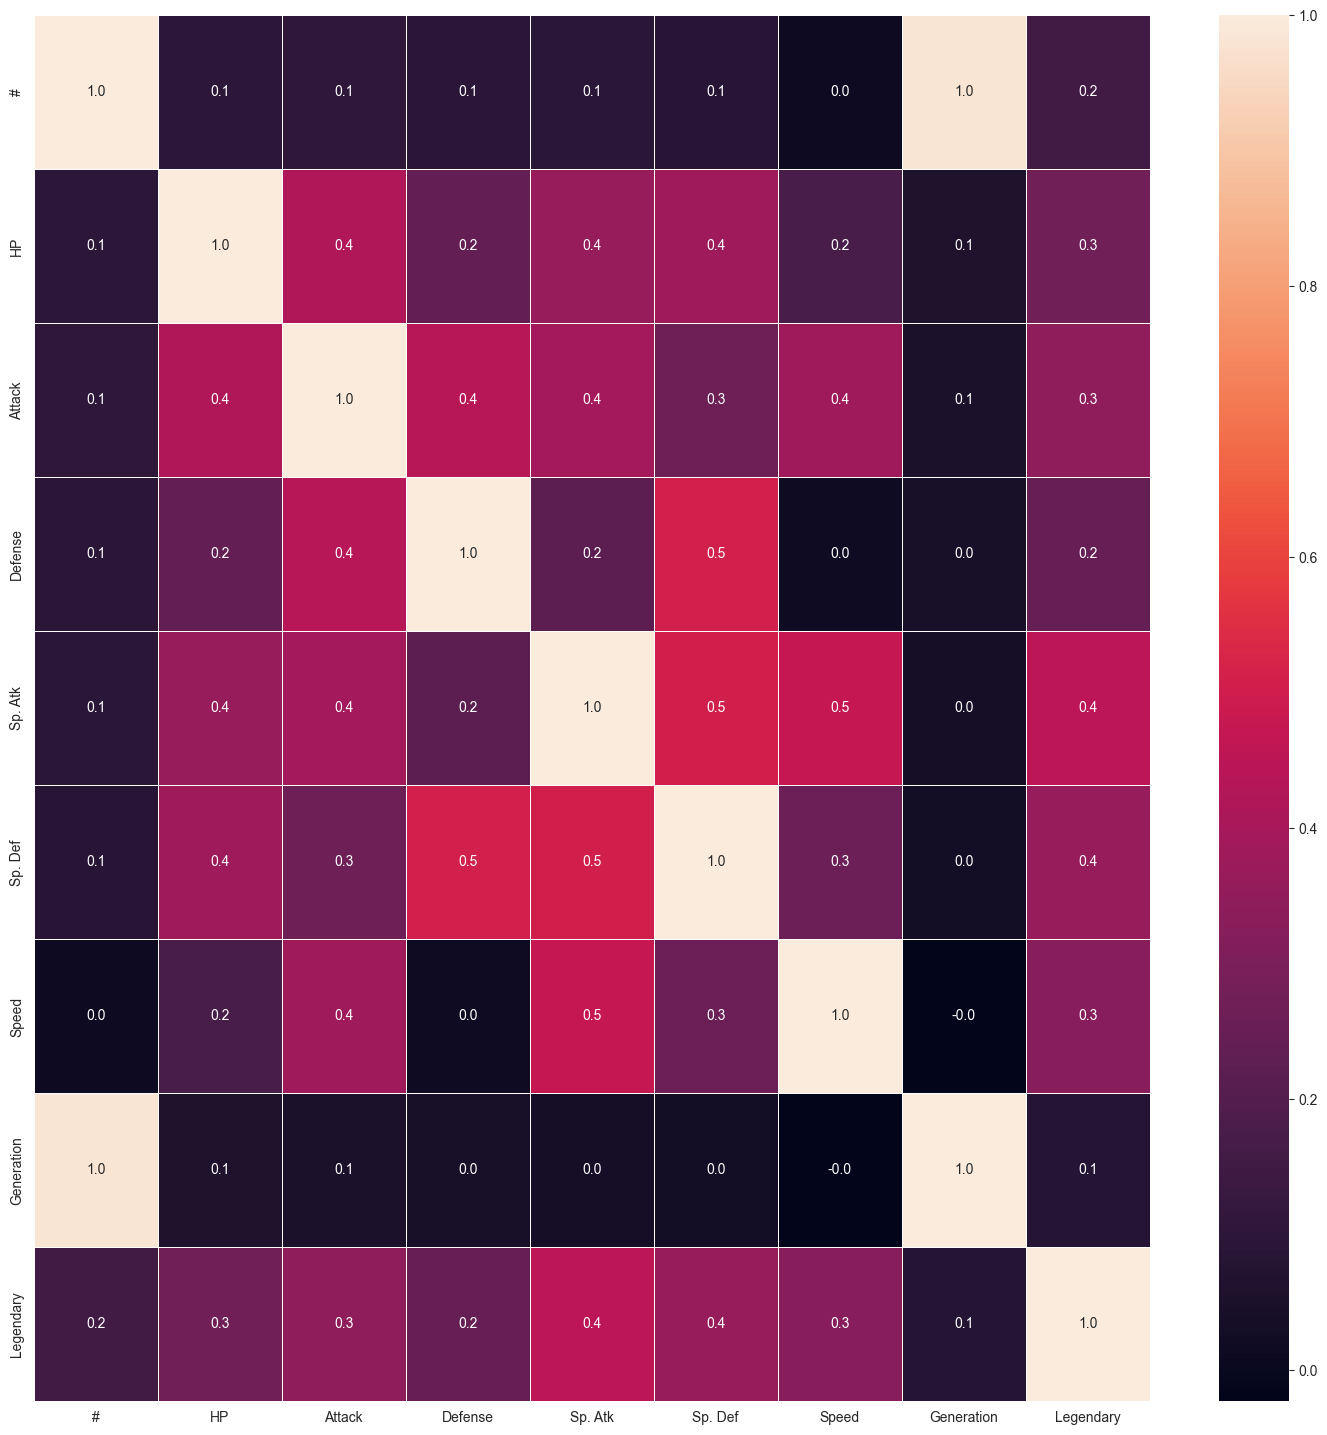

In [498]:
f,ax = plt.subplots(figsize=(18, 18))
sns.heatmap(data.corr(numeric_only=True), annot=True, linewidths=.5, fmt= '.1f',ax=ax)
plt.show()

In [499]:
data.head(10)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
5,6,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False
6,7,Charizard,Fire,Flying,78,84,78,109,85,100,1,False
7,8,Mega Charizard X,Fire,Dragon,78,130,111,130,85,100,1,False
8,9,Mega Charizard Y,Fire,Flying,78,104,78,159,115,100,1,False
9,10,Squirtle,Water,NaN,44,48,65,50,64,43,1,False


In [500]:
data.columns

Index(['#', 'Name', 'Type 1', 'Type 2', 'HP', 'Attack', 'Defense', 'Sp. Atk',
       'Sp. Def', 'Speed', 'Generation', 'Legendary'],
      dtype='object')

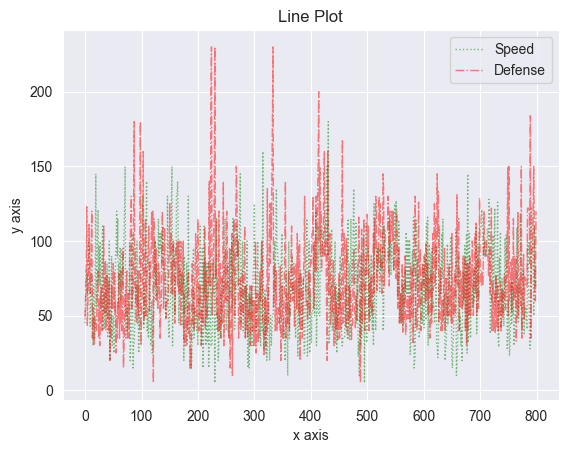

In [501]:
# Line Plot
# color = color, label = label, linewidth = width of line, alpha = opacity, grid = grid, linestyle = sytle of line
data.Speed.plot(kind = 'line', color = 'g',label = 'Speed',linewidth=1,alpha = 0.5,grid = True,linestyle = ':')
data.Defense.plot(color = 'r',label = 'Defense',linewidth=1, alpha = 0.5,grid = True,linestyle = '-.')
plt.legend(loc='upper right')     # legend = puts label into plot
plt.xlabel('x axis')              # label = name of label
plt.ylabel('y axis')
plt.title('Line Plot')            # title = title of plot
plt.show()

Text(0.5, 1.0, 'Attack Defense Scatter Plot')

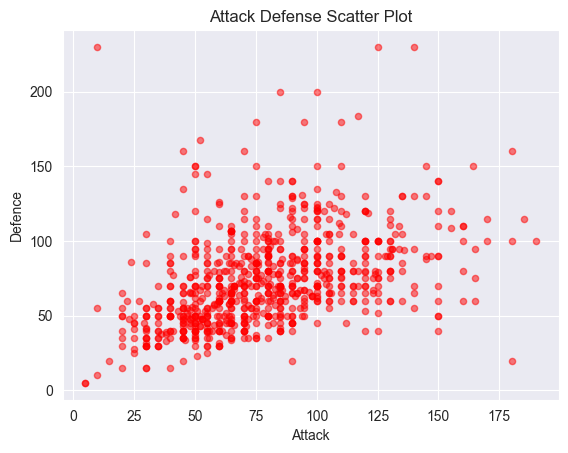

In [502]:
# Scatter Plot
# x = attack, y = defence
data.plot(kind='scatter', x='Attack', y='Defense',alpha = 0.5,color = 'red')
plt.xlabel('Attack')              # label = name of label
plt.ylabel('Defence')
plt.title('Attack Defense Scatter Plot')

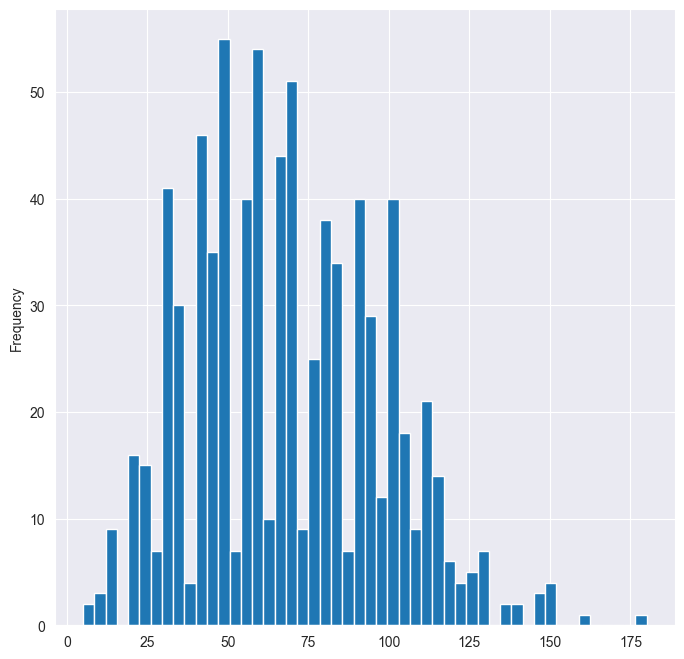

In [503]:
# Histogram
# bins = number of bar in figure
data.Speed.plot(kind = 'hist',bins = 50,figsize = (8,8))
plt.show()

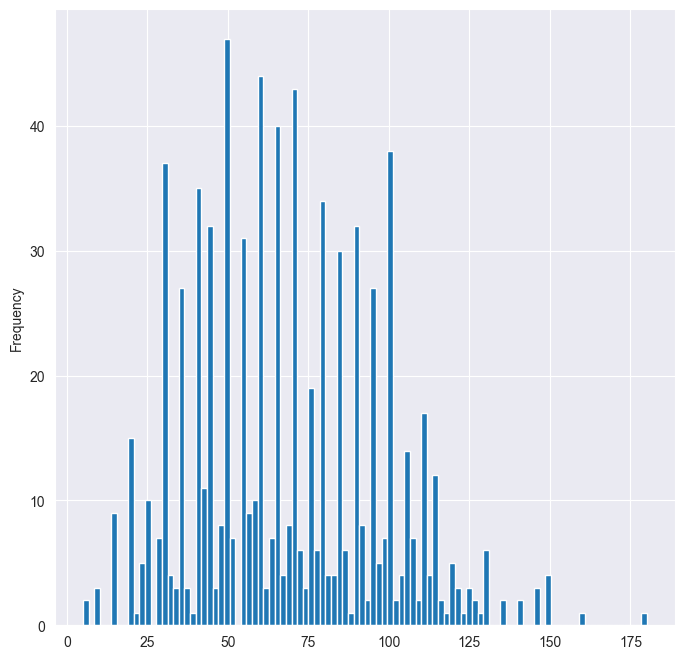

In [504]:
data.Speed.plot(kind = 'hist',bins = 100,figsize = (8,8))
plt.show()

In [505]:
series = data['Defense']        # data['Defense'] = series
print(type(series))
data_frame = data[['Defense']]  # data[['Defense']] = data frame
print(type(data_frame))
data.head(15)

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
5,6,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False
6,7,Charizard,Fire,Flying,78,84,78,109,85,100,1,False
7,8,Mega Charizard X,Fire,Dragon,78,130,111,130,85,100,1,False
8,9,Mega Charizard Y,Fire,Flying,78,104,78,159,115,100,1,False
9,10,Squirtle,Water,NaN,44,48,65,50,64,43,1,False


In [506]:
x = data['Defense']>175
data[x]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
87,88,Mega Slowbro,Water,Psychic,95,75,180,130,80,30,1,False
98,99,Cloyster,Water,Ice,50,95,180,85,45,70,1,False
223,224,Steelix,Steel,Ground,75,85,200,55,65,30,2,False
224,225,Mega Steelix,Steel,Ground,75,125,230,55,95,30,2,False
230,231,Shuckle,Bug,Rock,20,10,230,10,230,5,2,False
332,333,Aggron,Steel,Rock,70,110,180,60,60,50,3,False
333,334,Mega Aggron,Steel,NaN,70,140,230,60,80,50,3,False
414,415,Regirock,Rock,NaN,80,100,200,50,100,50,3,True
789,790,Avalugg,Ice,NaN,95,117,184,44,46,28,6,False


In [507]:
data[np.logical_and(data['Defense']>200, data['Attack']>125 )]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
333,334,Mega Aggron,Steel,NaN,70,140,230,60,80,50,3,False


<Axes: >

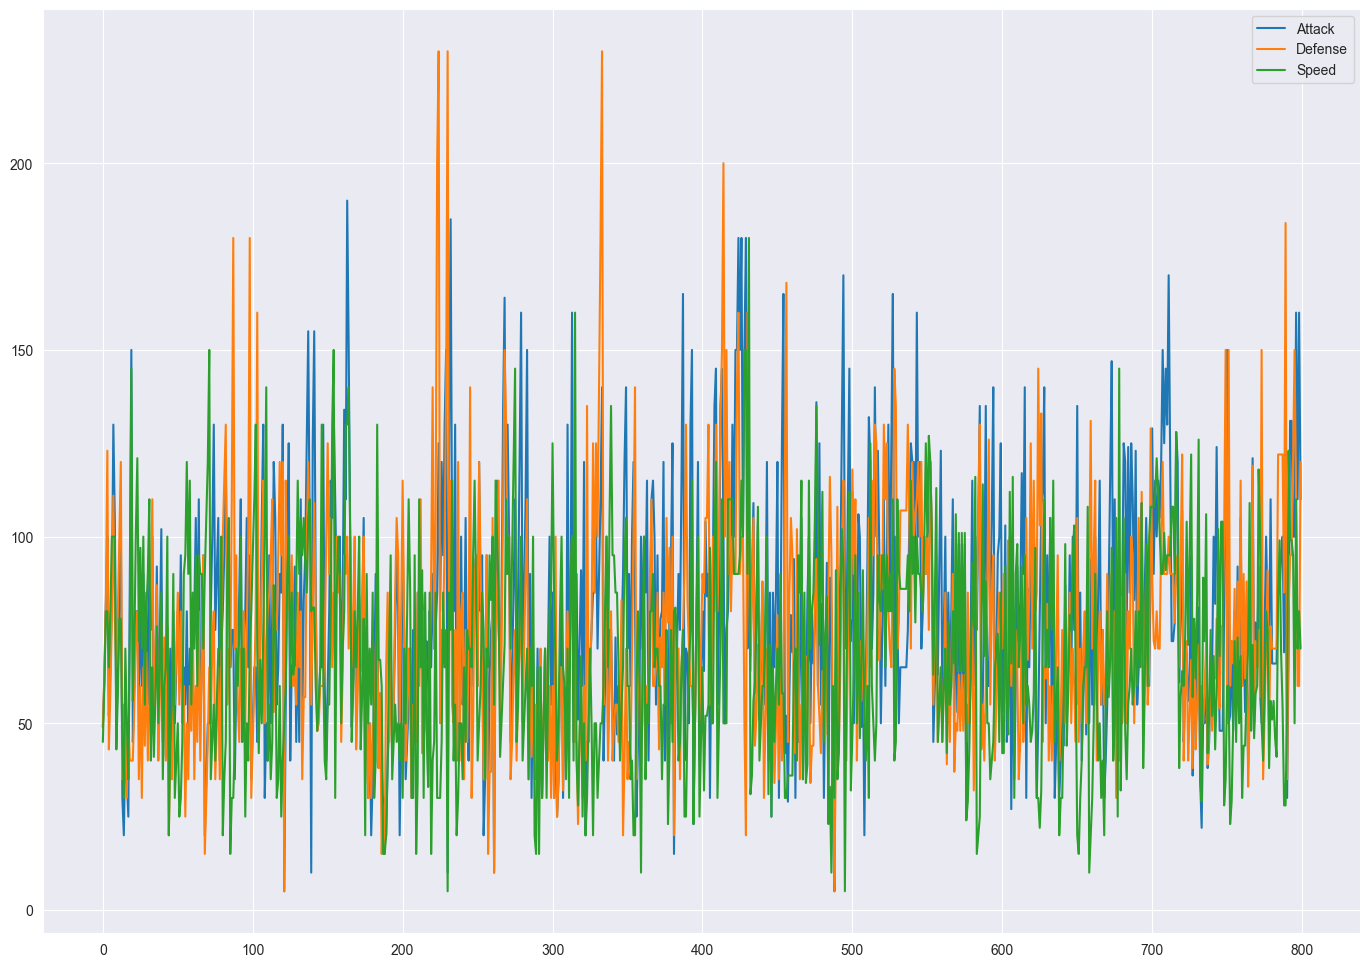

In [508]:
data1 = data.loc[:,["Attack","Defense","Speed"]]
data1.plot(figsize = (17,12))

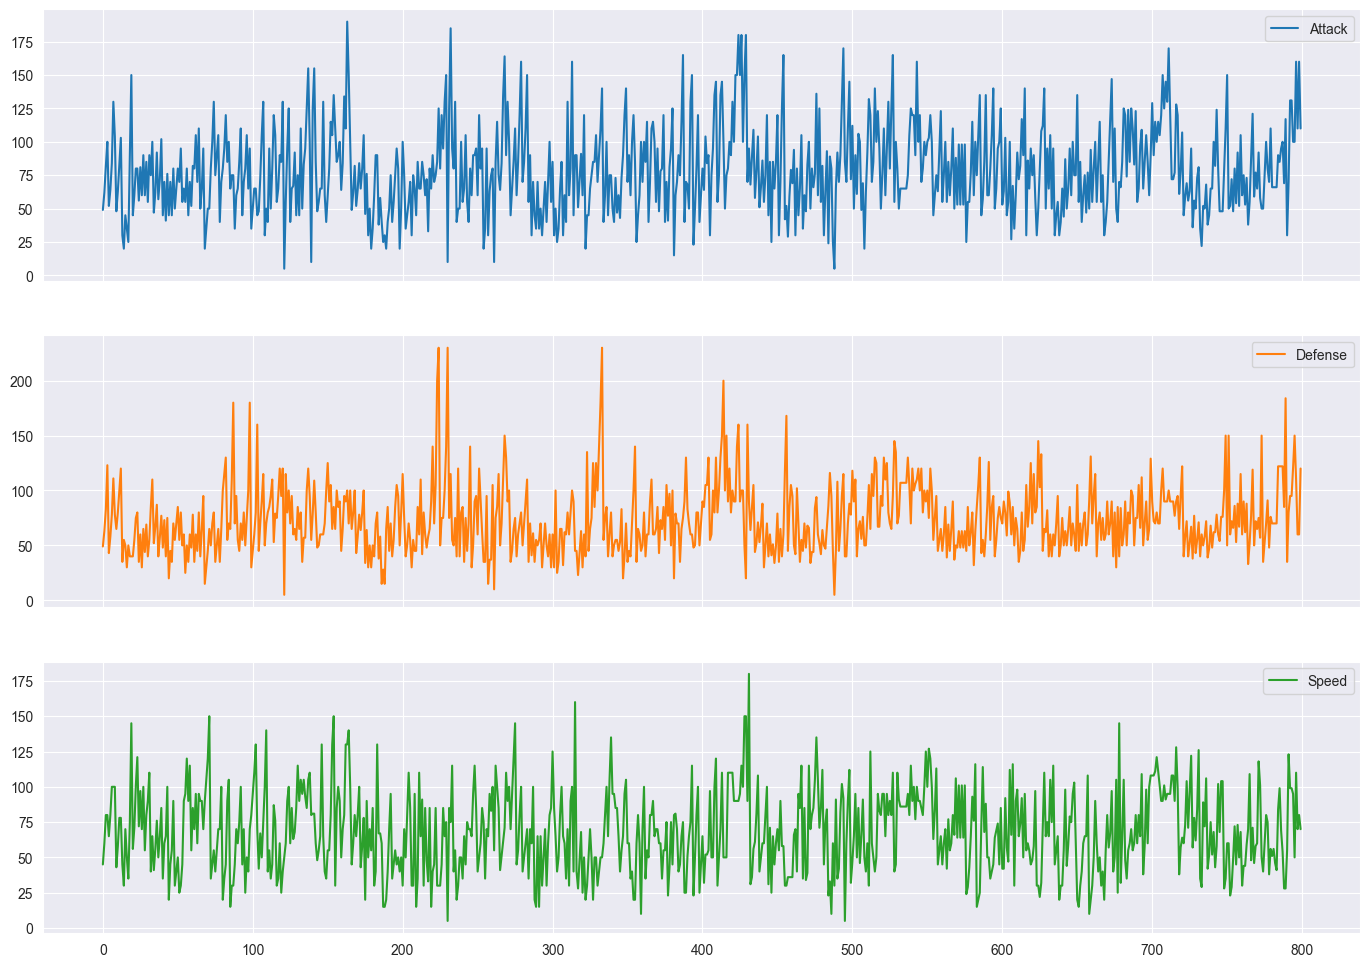

In [509]:
data1.plot(subplots = True,figsize = (17,12))
plt.show()

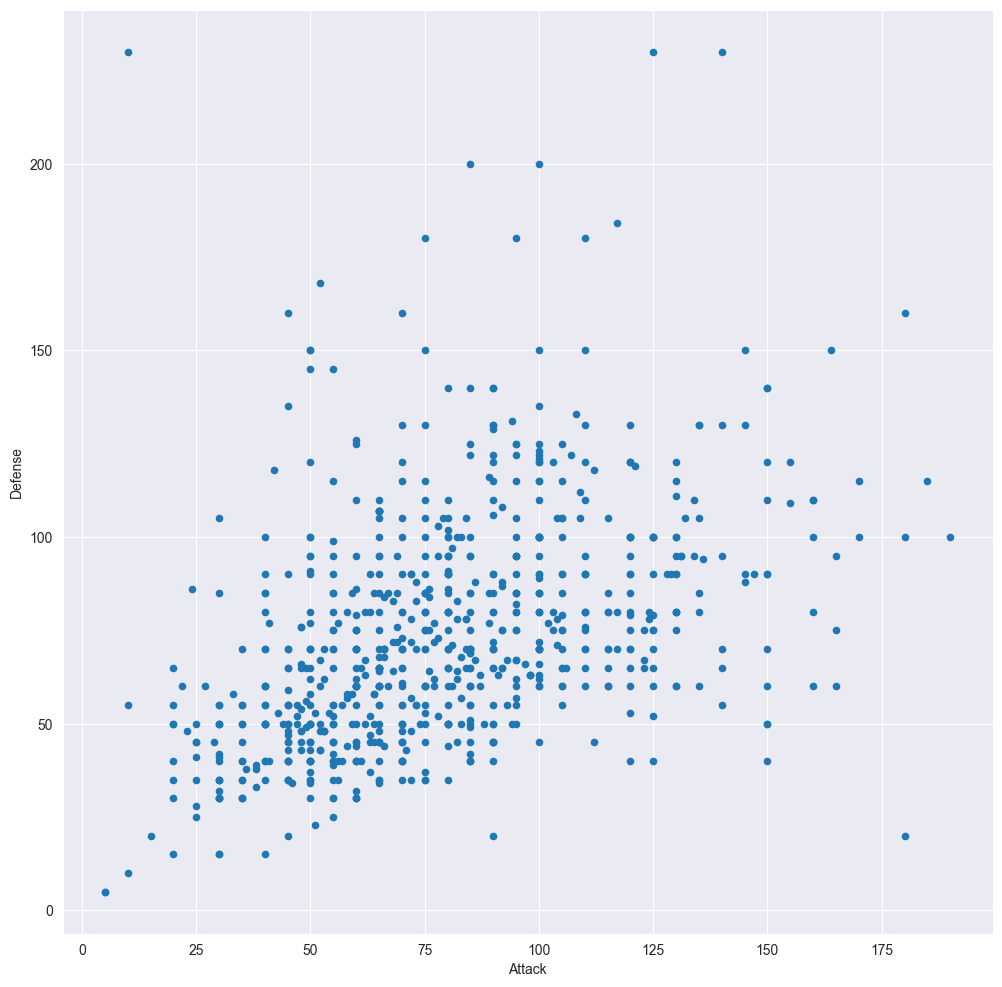

In [510]:
data1.plot(kind = "scatter",x="Attack",y = "Defense",figsize = (12,12))
plt.show()

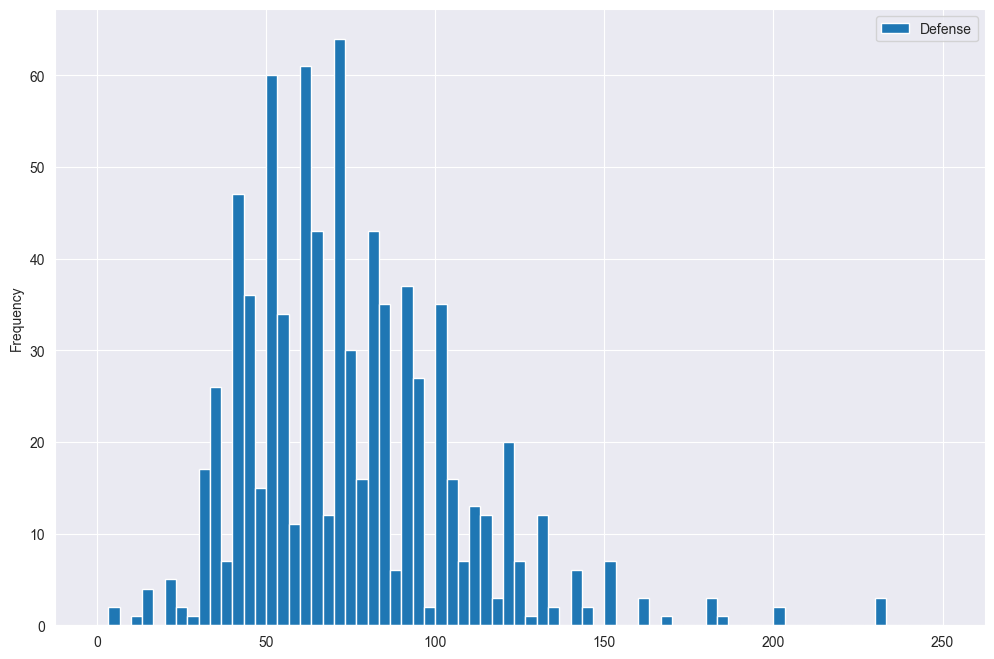

In [511]:
data1.plot(kind = "hist",y = "Defense",bins = 75,range= (0,250), figsize = (12,8))
plt.show()
plt.show()

<module 'matplotlib.pyplot' from 'C:\\Users\\Admin\\PycharmProjects\\Lb2\\.venv\\Lib\\site-packages\\matplotlib\\pyplot.py'>

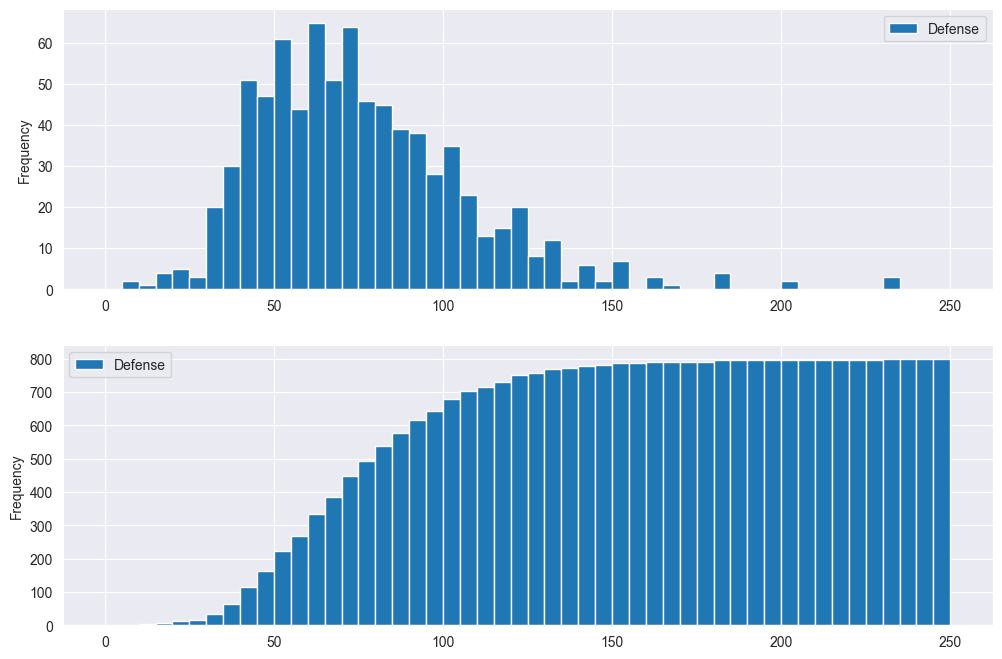

In [512]:
fig, axes = plt.subplots(nrows=2,ncols=1)
data1.plot(kind = "hist",y = "Defense",bins = 50,range= (0,250),ax = axes[0],figsize = (12,8))
data1.plot(kind = "hist",y = "Defense",bins = 50,range= (0,250),ax = axes[1],figsize = (12,8),cumulative = True)
plt

<Axes: title={'center': 'Attack'}, xlabel='Legendary'>

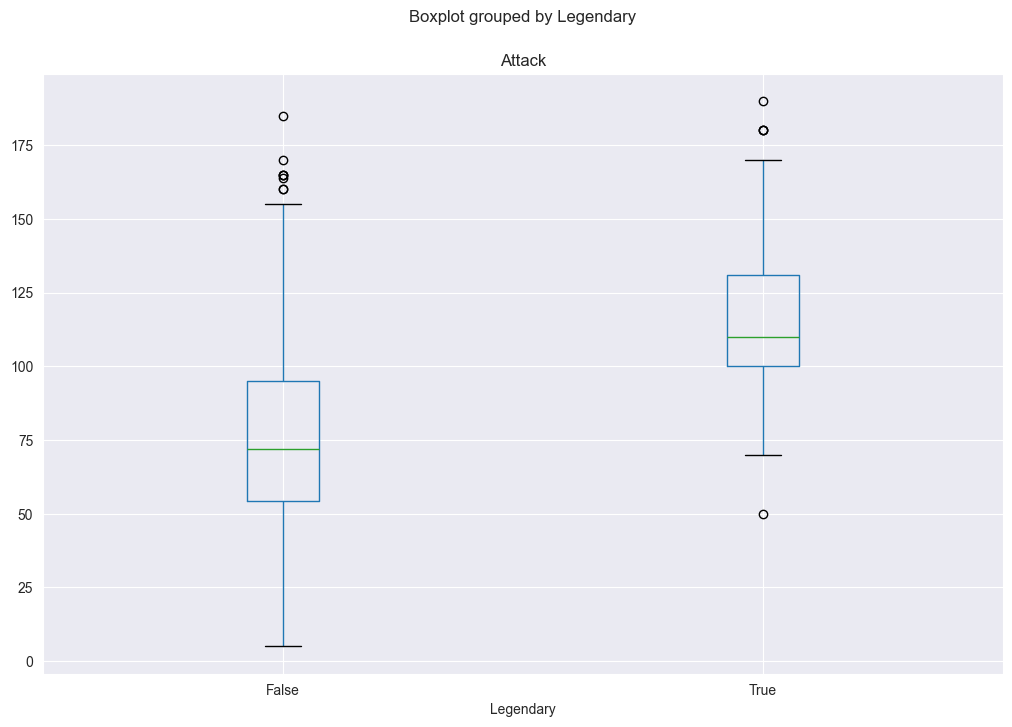

In [513]:
data.boxplot(column='Attack',by = 'Legendary',figsize = (12,8))

<Axes: xlabel='Winner'>

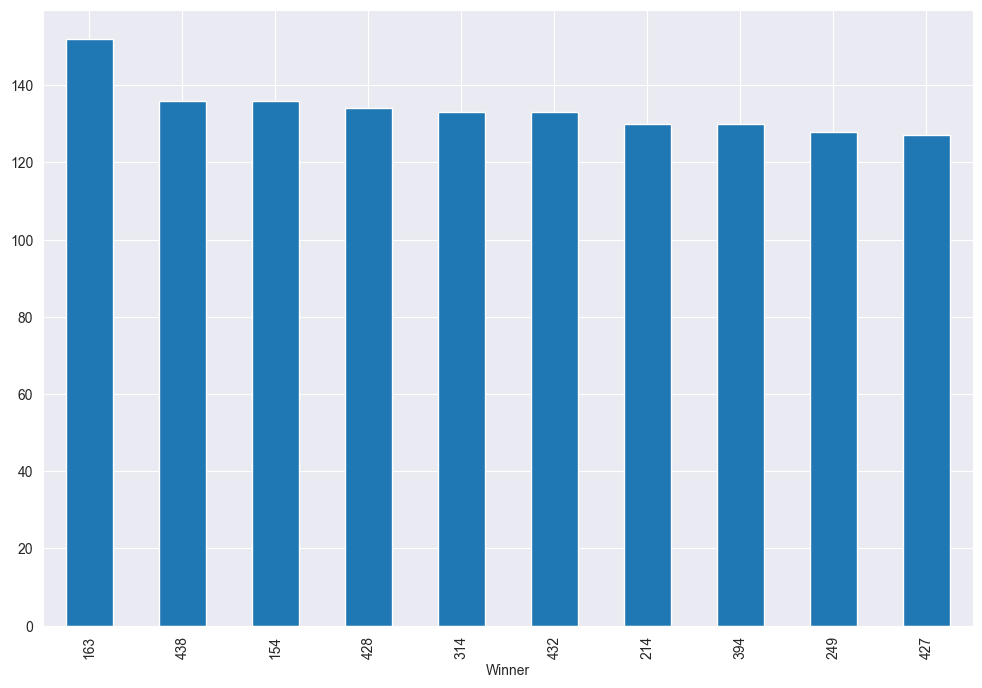

In [514]:
win_counts = data_comb['Winner'].value_counts()
win_counts.head(10).plot(kind='bar',figsize = (12,8))

<Axes: ylabel='Name'>

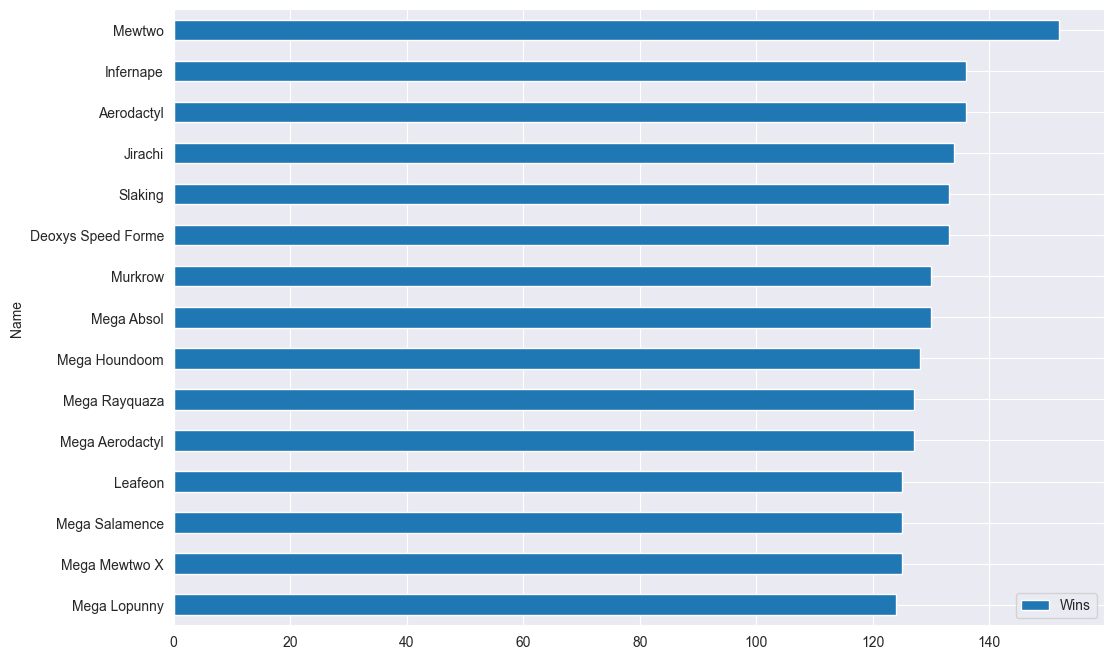

In [515]:
wins = data_comb['Winner'].value_counts().reset_index()
wins.columns = ['ID', 'Wins']
wins = wins.merge(data, left_on='ID', right_on='#')
wins.sort_values('Wins', ascending=True).tail(15).plot(x='Name', y='Wins', kind='barh',figsize = (12,8))


<Axes: ylabel='Name'>

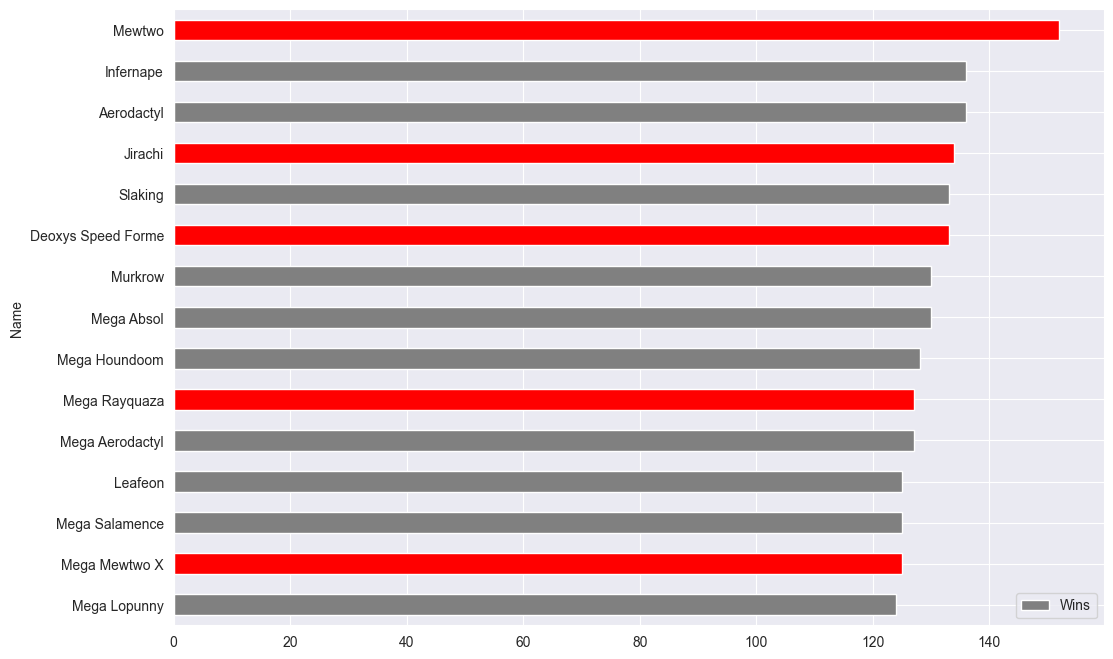

In [516]:
wins.sort_values('Wins')
top15 = wins.sort_values('Wins').tail(15)
colors = top15['Legendary'].map({True: 'red',False: 'gray'}) #red color means legendary rarity
wins.sort_values('Wins').tail(15).plot(x='Name',y='Wins',kind='barh',color=colors,figsize = (12,8))

In [517]:
#Cleaning data

In [518]:
data = pd.read_csv('C:/Users/Admin/Documents/Lb2(pokemon)/pokemon.csv')
data.head()


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [519]:
data.tail()

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
795,796,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True
796,797,Mega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True
797,798,Hoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True
798,799,Hoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True
799,800,Volcanion,Fire,Water,80,110,120,130,90,70,6,True


In [520]:
data.shape

(800, 12)

In [521]:
print(data['Type 1'].value_counts(dropna =False))


Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Rock         44
Electric     44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64


In [522]:
data.describe()

,#,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.0000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,400.5000,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,231.0844,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.0000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,200.7500,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,400.5000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,600.2500,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,800.0000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [523]:
data_new = data.head(3)    # I only take 5 rows into new data
data_new

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False


In [524]:
cleansed = pd.melt(frame=data_new,id_vars = 'Name', value_vars= ['Attack','Defense'])
cleansed

,Name,variable,value
0,Bulbasaur,Attack,49
1,Ivysaur,Attack,62
2,Venusaur,Attack,82
3,Bulbasaur,Defense,49
4,Ivysaur,Defense,63
5,Venusaur,Defense,83


In [525]:
cleansed.pivot(index = 'Name', columns = 'variable',values='value')

variable,Attack,Defense
Name,,
Bulbasaur,49,49
Ivysaur,62,63
Venusaur,82,83


In [526]:
data1 = data.head()
data2= data.tail()
conc_data_row = pd.concat([data1,data2],axis =0,ignore_index =True)
conc_data_row

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
5,796,Diancie,Rock,Fairy,50,100,150,100,150,50,6,True
6,797,Mega Diancie,Rock,Fairy,50,160,110,160,110,110,6,True
7,798,Hoopa Confined,Psychic,Ghost,80,110,60,150,130,70,6,True
8,799,Hoopa Unbound,Psychic,Dark,80,160,60,170,130,80,6,True
9,800,Volcanion,Fire,Water,80,110,120,130,90,70,6,True
